# Module 2 — Analytics Pipeline: EDA (Titanic)

Loads the Titanic dataset once via `sns.load_dataset('titanic')`, saves a committed
`titanic.csv` offline fallback, profiles it, cleans missing values per column, and
builds the EDA "data story" (univariate, bivariate, multivariate, correlation heatmap).
`02_modeling.ipynb` continues from the same cleaned data.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load once from seaborn's bundled loader. This hits the network only the
# first time (or whenever the local seaborn cache is empty) -- after that
# seaborn reuses its own cache, and everything downstream reads titanic.csv.
df = sns.load_dataset('titanic')

# Committed offline fallback so the notebook (and 02_modeling.ipynb) can be
# graded without network access. This is the ONE load of the raw dataset.
df.to_csv("titanic.csv", index=False)

print(df.shape)
df.info()
df.describe()


(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Missing values

Which columns have gaps, and how big are they, before deciding what to do about each one.

In [2]:
# Only columns with at least one missing value are worth reporting.
missing_pct = (df.isna().mean() * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
missing_pct


deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
dtype: float64

## Cleaning

Applying a simple threshold rule per column: drop rows if barely anything's missing, impute if it's a moderate amount, and think harder (impute vs. drop the column) if it's mostly gaps.

In [3]:
# Threshold rule: <5% missing -> drop rows, 5-30% -> impute, too sparse to
# impute reliably -> drop the column (or encode "missing", see below).

# embarked / embark_town: 0.22% missing, well under 5% -> just drop those rows.
df = df.dropna(subset=['embarked', 'embark_town'])

# age: 19.87% missing, in the 5-30% band -> impute with the median rather
# than the mean, since age has real outliers/skew that would drag a mean up.
df['age'] = df['age'].fillna(df['age'].median())

# deck: 77.22% missing -- too sparse to impute reliably, and it isn't used
# anywhere downstream (not in the correlation matrix, not one-hot encoded
# for modeling), so an encoded "missing" category would mostly just record
# that data collection failed rather than a real passenger attribute. Drop it.
df = df.drop(columns=['deck'])

df.isna().sum()  # confirm zero missing values remain


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## Univariate analysis — age and fare

IQR-based outlier counts and a look at each distribution's shape.

In [4]:
# IQR rule: anything outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] counts as an outlier.
Q1_age, Q3_age = df['age'].quantile([0.25, 0.75])
IQR_age = Q3_age - Q1_age
age_outliers = df[(df['age'] < Q1_age - 1.5*IQR_age) | (df['age'] > Q3_age + 1.5*IQR_age)]

Q1_fare, Q3_fare = df['fare'].quantile([0.25, 0.75])
IQR_fare = Q3_fare - Q1_fare
fare_outliers = df[(df['fare'] < Q1_fare - 1.5*IQR_fare) | (df['fare'] > Q3_fare + 1.5*IQR_fare)]

print("age outliers:", len(age_outliers))
print("fare outliers:", len(fare_outliers))

fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()[0]  # mode() returns a Series since a column can have multiple modes; [0] takes the first
print(fare_mean, fare_median, fare_mode)


age outliers: 65
fare outliers: 114
32.09668087739032 14.4542 8.05


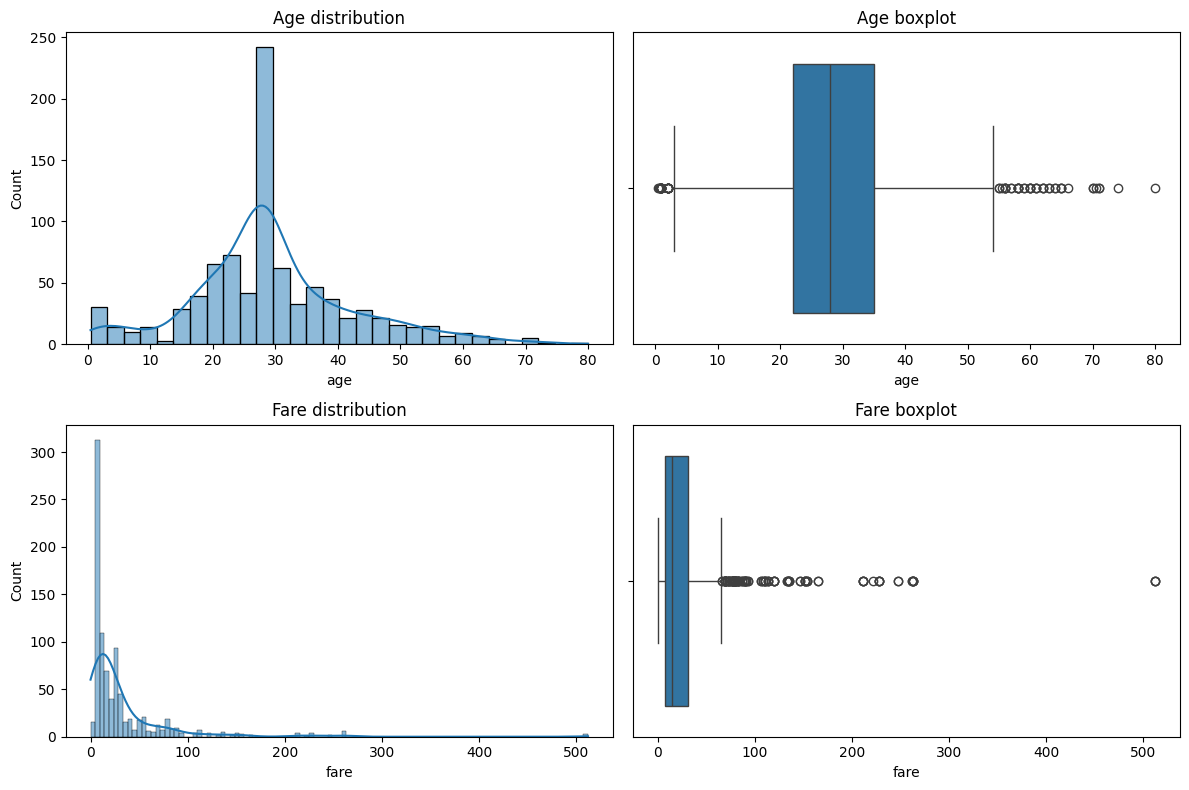

In [5]:
# Histogram + box plot side by side for both columns -- the histogram shows
# shape/skew, the box plot makes the IQR outliers from the previous cell visible.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['age'], kde=True, ax=axes[0, 0]).set_title('Age distribution')
sns.boxplot(x=df['age'], ax=axes[0, 1]).set_title('Age boxplot')
sns.histplot(df['fare'], kde=True, ax=axes[1, 0]).set_title('Fare distribution')
sns.boxplot(x=df['fare'], ax=axes[1, 1]).set_title('Fare boxplot')
plt.tight_layout()
plt.show()


## Bivariate analysis

Survival rate broken down by sex, class, and both together — then a correlation matrix across the numeric columns.

In [6]:
# Survival rate broken down three ways, via boolean masking rather than
# groupby, since the task specifically calls for the & / | mask style.

# (a) by sex
for sex in ['male', 'female']:
    rate = df[df['sex'] == sex]['survived'].mean()
    print(f"{sex}: {rate:.3f}")

# (b) by pclass
for pc in sorted(df['pclass'].unique()):
    rate = df[df['pclass'] == pc]['survived'].mean()
    print(f"pclass {pc}: {rate:.3f}")

# (c) sex + pclass combined -- this is the breakdown that actually reveals
# whether sex or class is the dominant factor (see cell below / README).
for sex in ['male', 'female']:
    for pc in sorted(df['pclass'].unique()):
        rate = df[(df['sex'] == sex) & (df['pclass'] == pc)]['survived'].mean()
        print(f"{sex}, pclass {pc}: {rate:.3f}")


male: 0.189
female: 0.740
pclass 1: 0.626
pclass 2: 0.473
pclass 3: 0.242
male, pclass 1: 0.369
male, pclass 2: 0.157
male, pclass 3: 0.135
female, pclass 1: 0.967
female, pclass 2: 0.921
female, pclass 3: 0.500


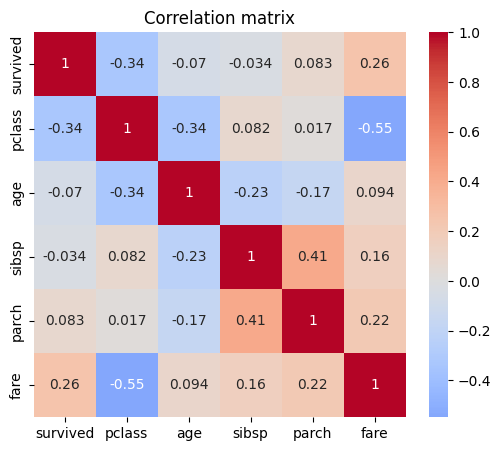

fare    pclass    0.548193
pclass  fare      0.548193
parch   sibsp     0.414542
sibsp   parch     0.414542
dtype: float64

In [7]:
# Restricted to the 6 numeric/target columns the task specifies. adult_male
# and alone are excluded because they're derived flags (computed directly
# from sex/age and sibsp+parch), not independent measured features -- including
# them would just restate correlations already visible elsewhere in the matrix.
corr_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

# Rank every off-diagonal pair by |correlation| to pull out the two strongest
# relationships (unstack() turns the matrix into a pair-indexed series;
# `< 1` drops the self-correlated diagonal before sorting).
pairs = corr_matrix.abs().unstack()
pairs = pairs[pairs < 1]
pairs.sort_values(ascending=False).head(4)


## Multivariate data story

Four charts, each meant to add a different piece to the "who survived and why" picture. Interpretations are in the README.

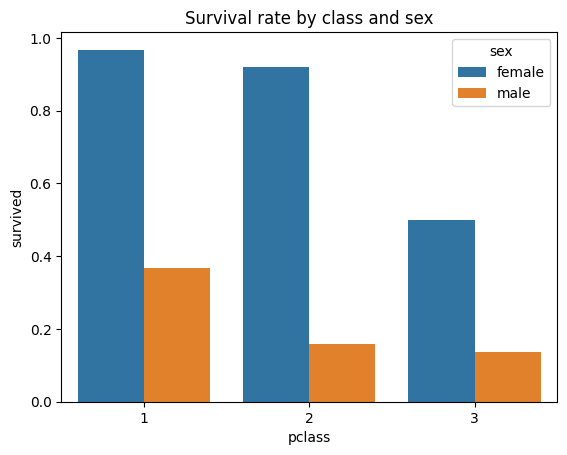

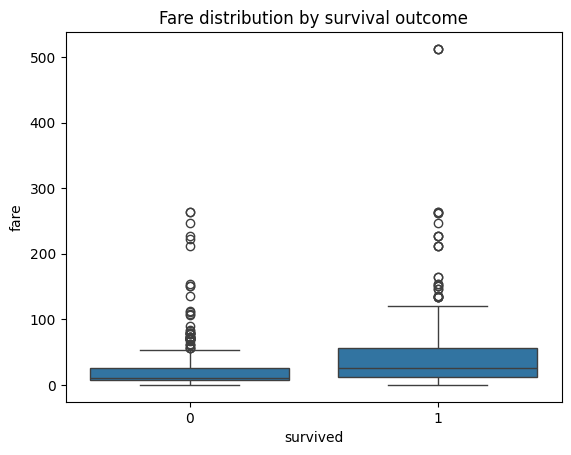

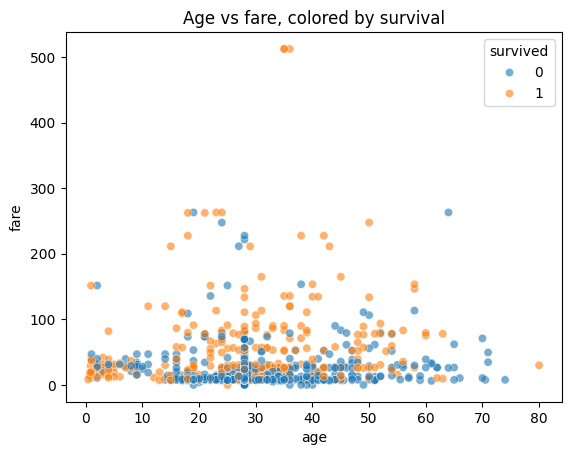

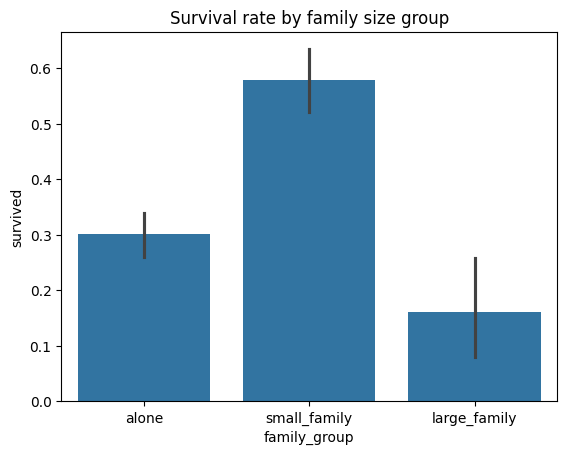

In [8]:
# Four charts that together build the "who survived and why" story --
# interpretations for each are written up in the README.

# 1. grouped bar: survival rate by sex x pclass
sex_pclass = df.groupby(['pclass', 'sex'])['survived'].mean().reset_index()
sns.barplot(data=sex_pclass, x='pclass', y='survived', hue='sex')
plt.title('Survival rate by class and sex')
plt.show()

# 2. box plot: fare by survived
sns.boxplot(data=df, x='survived', y='fare')
plt.title('Fare distribution by survival outcome')
plt.show()

# 3. scatter: age vs fare, colored by survived
sns.scatterplot(data=df, x='age', y='fare', hue='survived', alpha=0.6)
plt.title('Age vs fare, colored by survival')
plt.show()

# 4. bar: survival rate by family size group. sibsp + parch gives total
# family members aboard; binned into alone / small / large rather than used
# raw, since the effect turns out to be non-monotonic (see README).
df['family_size'] = df['sibsp'] + df['parch']
df['family_group'] = pd.cut(df['family_size'], bins=[-1, 0, 3, 10], labels=['alone', 'small_family', 'large_family'])
sns.barplot(data=df, x='family_group', y='survived')
plt.title('Survival rate by family size group')
plt.show()


## Standardization sanity check

A quick EDA-only check that z-scoring `age`/`fare` behaves as expected. Doesn't feed into modeling — that pipeline does its own train-only scaling.

In [9]:
# EDA-only sanity check that z-scoring works as expected -- this does NOT
# feed into the modeling pipeline, which does its own train-only scaling
# (fitting a scaler here on the full dataset would leak test-set stats).
from sklearn.preprocessing import StandardScaler

print("before:")
print(df[['age', 'fare']].agg(['mean', 'std']))

scaler = StandardScaler()
scaled = scaler.fit_transform(df[['age', 'fare']])
scaled_df = pd.DataFrame(scaled, columns=['age_z', 'fare_z'])

print("after:")
print(scaled_df.agg(['mean', 'std']))


before:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504
after:
             age_z        fare_z
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00
